#  Principal Component Analysis

In our previous classes, we have been learning about the supervised learning estimators in Scikit-Learn:

-  estimators that predict labels based on labeled training data.

In this class, we are going to learn about an unsupervised estimator, principal component analysis (PCA) that can highlight interesting aspects of the data without reference to any known labels. PCA is a dimensionality reduction algorithm. It can also be useful as a tool for visualization, for noise filtering, for feature extraction and engineering. After a brief conceptual discussion of the PCA algorithm, we are going to practice PCA on an example.

Let us begin with the standard imports:

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

## Introducing Principal Component Analysis

Principal component analysis is a fast and flexible unsupervised method for dimensionality reduction in data. Its behavior is easiest to visualize by looking at a two-dimensional dataset. Let us generate a two-dimensional dataset and visualize it with a scatter plot as follows:

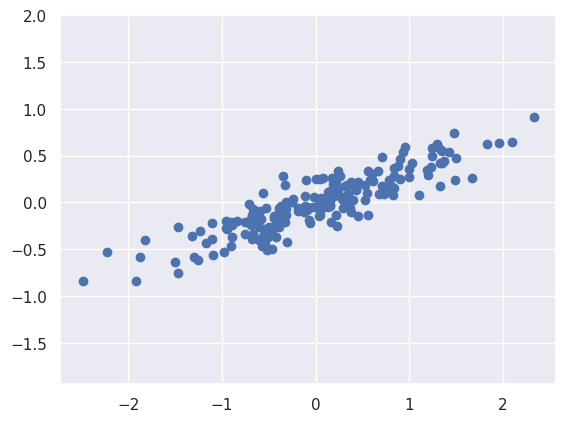

In [2]:
# set the random seed for reproducibility
rng = np.random.RandomState(1)

# rand() creates an array of the given shape and populates it with random samples from a uniform distribution over [0, 1).
# randn() creates an array of the given shape, fills with random samples from a univariate “normal” distribution of mean 0 and variance 1.
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal');

Visual observation:

- there is a linear relationship between the x and y variables

A linear regression model tries to *predict* the y values from the x values. However, the unsupervised learning problem here attempts to learn about the **relationship** between the x and y values.

In principal component analysis, this relationship is quantified by finding a list of the **principal axes** in the data, and using those axes to describe the dataset. Using Scikit-Learn's ``PCA`` estimator, we can compute this as follows:

In [3]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)  # n_components: Number of components to keep
pca.fit(X)

PCA(n_components=2)

The fit learns some quantities from the data, most importantly:
- **components** (i.e, .components_)
- **explained variance** (i.e., .explained_variance_)

In [4]:
print(pca.components_)

[[ 0.94446029  0.32862557]
 [-0.32862557  0.94446029]]


In [5]:
print(pca.explained_variance_)

[0.7625315 0.0184779]


To see what these numbers mean, let's visualize them as vectors over the input data:

- using the "components" to define the direction of the vector, and
- the "explained variance" to define the squared-length of the vector

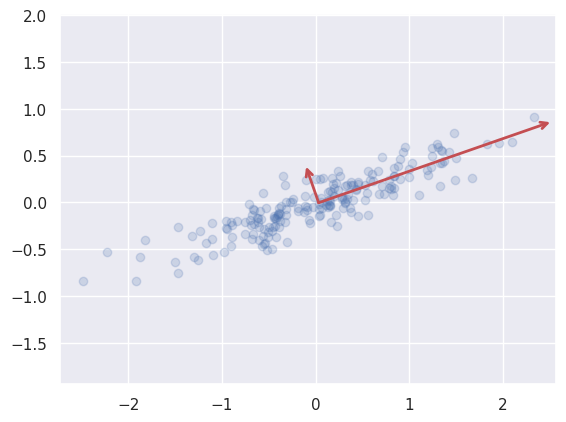

In [5]:
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2,
                    shrinkA=0, shrinkB=0, color='r')
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.scatter(X[:, 0], X[:, 1], alpha=0.2)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');

- These vectors represent the *principal axes* of the data.
- The length of the vector is an indication of how "important" that axis is in describing the distribution of the data—more precisely, it is a measure of the variance of the data when projected onto that axis.
- The projection of each data point onto the principal axes are the "principal components" of the data.

If we plot these principal components beside the original data, we see the plots shown here:

[Text(0.5, 0, 'component 1'),
 Text(0, 0.5, 'component 2'),
 Text(0.5, 1.0, 'principal components'),
 (-5.0, 5.0),
 (-3.0, 3.1)]

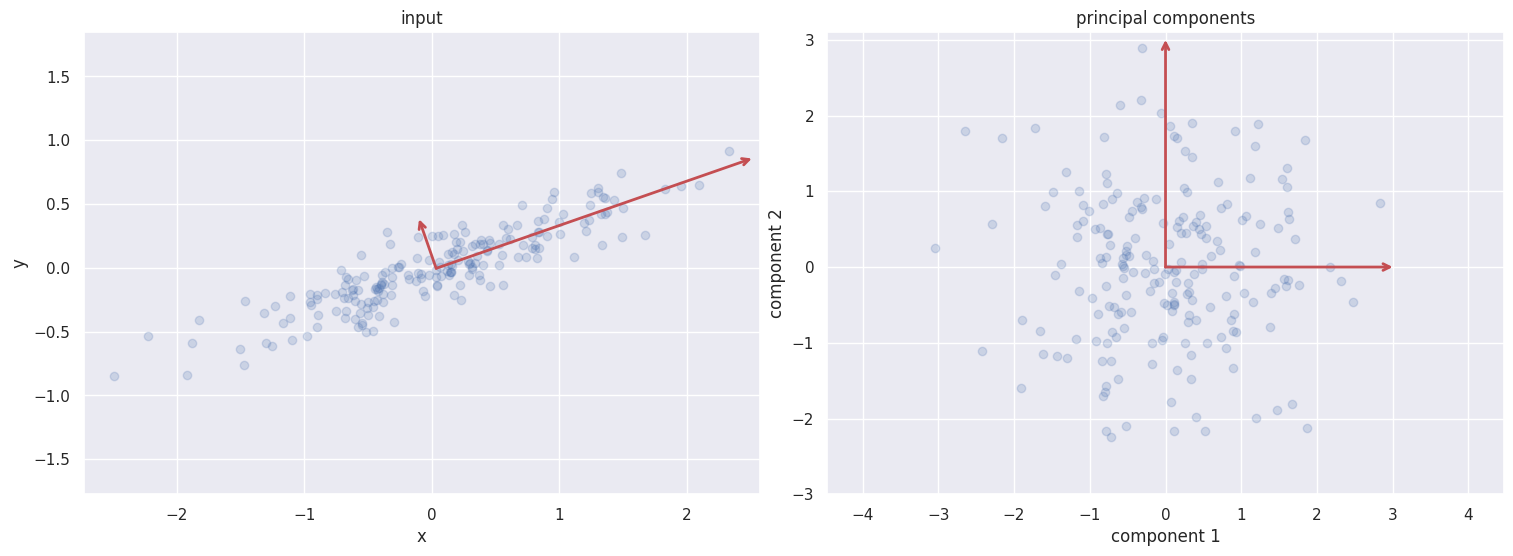

In [9]:
rng = np.random.RandomState(1)
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T
pca = PCA(n_components=2, whiten=True)
pca.fit(X)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

# plot data
ax[0].scatter(X[:, 0], X[:, 1], alpha=0.2)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v, ax=ax[0])
ax[0].axis('equal');
ax[0].set(xlabel='x', ylabel='y', title='input')

# plot principal components
X_pca = pca.transform(X)
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.2)
draw_vector([0, 0], [0, 3], ax=ax[1])
draw_vector([0, 0], [3, 0], ax=ax[1])
ax[1].axis('equal')
ax[1].set(xlabel='component 1', ylabel='component 2',
          title='principal components',
          xlim=(-5, 5), ylim=(-3, 3.1))


This transformation from <font color="red">data axes</font> to <font color="green">principal axes</font> is an *affine transformation*: it is composed of a
-  translation,
- rotation, and
- uniform scaling.

Finding principal components has important applications in maching learning and data exploration!

### PCA as dimensionality reduction

Using PCA for dimensionality reduction involves zeroing out one or more of the smallest principal components, resulting in a lower-dimensional projection of the data that preserves the maximal data variance.

Here is an example of using PCA as a dimensionality reduction transform:

In [7]:
pca = PCA(n_components=1)
pca.fit(X)
X_pca = pca.transform(X)
print("original shape:   ", X.shape)
print("transformed shape:", X_pca.shape)

original shape:    (200, 2)
transformed shape: (200, 1)


The transformed data has been reduced to a single dimension.
To understand the effect of this dimensionality reduction, we can perform the inverse transform of this reduced data and plot it along with the original data:

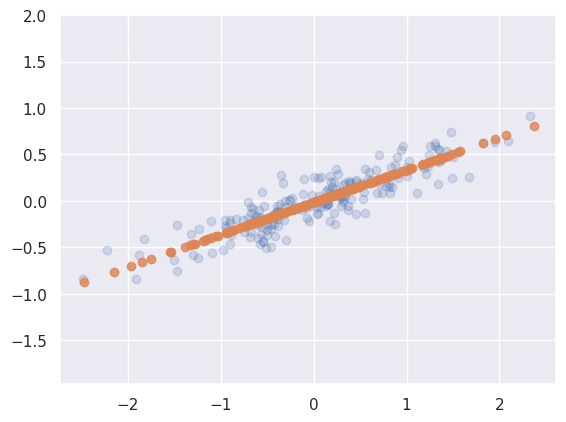

In [8]:
X_new = pca.inverse_transform(X_pca)
plt.scatter(X[:, 0], X[:, 1], alpha=0.2)
plt.scatter(X_new[:, 0], X_new[:, 1], alpha=0.8)
plt.axis('equal');

The light points are the original data, while the dark points are the projected version.

In other words, through PCA dimensionality reduction, the information along the least important principal axis or axes is removed, leaving only the component(s) of the data with the highest variance. This reduced-dimension dataset is in some senses "good enough" to encode the most important relationships between the points: despite reducing the dimension of the data by 50%, the overall relationship between the data points are mostly preserved.

### PCA for visualization: Hand-written digits

The usefulness of the dimensionality reduction becomes much more clear when looking at a high-dimensional data.
To see this, let's take a quick look at the application of PCA to the hand-written digits data that we used in illustrating Random Forests.

In [10]:
# loading the data
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape # note: high-dimensional data


(1797, 64)

Recall that the data consists of 8×8 pixel images, meaning that they are 64-dimensional.
To gain some intuition into the relationships between these points, we can use PCA to project them to a more manageable number of dimensions, say two:

In [11]:
pca = PCA(2)  # project from 64 to 2 dimensions
projected = pca.fit_transform(digits.data)

print(digits.data.shape)      # original data shape
print(projected.shape)        # projected data shape

(1797, 64)
(1797, 2)


In [12]:
projected

array([[ -1.25946645, -21.27488348],
       [  7.9576113 ,  20.76869896],
       [  6.99192297,   9.95598641],
       ...,
       [ 10.8012837 ,   6.96025223],
       [ -4.87210009, -12.42395362],
       [ -0.34438963,  -6.36554919]])

We can now plot the first two principal components of each point to learn about the data:

<ipython-input-13-550d20087798>:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Accent', 10))


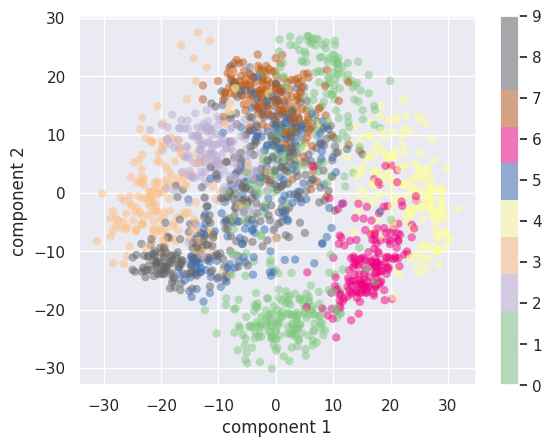

In [13]:
plt.scatter(projected[:, 0], projected[:, 1],
            c=digits.target, edgecolor='none', alpha=0.5,
            cmap=plt.cm.get_cmap('Accent', 10))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.colorbar();

The full data consists of 64-dimension. Principal components in the above plot imply that:
- these points are the projection of each data point along the directions with the largest variance.

In other words, through unsupervised learning process (without any references to the labels), we obtained the optimal stretch and rotation in 64 dimensional space so that we can see the layout of the digits in only 2 dimensions!

### What do the components mean?

We can go a bit further here, and begin to ask what the reduced dimensions *mean*.
This meaning can be understood in terms of combinations of basis vectors.
For example, each image in the training set is defined by a collection of 64 pixel values, which we will call the vector $x$:

$$
x = [x_1, x_2, x_3 \cdots x_{64}]
$$

One way we can think about this is in terms of a pixel basis.
That is, to construct the image, we multiply each element of the vector by the pixel it describes, and then add the results together to build the image:

$$
{\rm image}(x) = x_1 \cdot{\rm (pixel~1)} + x_2 \cdot{\rm (pixel~2)} + x_3 \cdot{\rm (pixel~3)} \cdots x_{64} \cdot{\rm (pixel~64)}
$$

One way we might imagine reducing the dimension of this data is to zero out all but a few of these basis vectors.
For example, if we use only the first eight pixels, we get an eight-dimensional projection of the data, but it is not very reflective of the whole image: we've thrown out nearly 90% of the pixels!

![](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/figures/05.09-digits-pixel-components.png?raw=1)

The upper row of panels shows the individual pixels, and the lower row shows the cumulative contribution of these pixels to the construction of the image.
Using only eight of the pixel-basis components, we can only construct a small portion of the 64-pixel image.
Were we to continue this sequence and use all 64 pixels, we would recover the original image.

But the pixel-wise representation is not the only choice of basis. We can also use other basis functions, which each contain some pre-defined contribution from each pixel, and write something like

$$
image(x) = {\rm mean} + x_1 \cdot{\rm (basis~1)} + x_2 \cdot{\rm (basis~2)} + x_3 \cdot{\rm (basis~3)} \cdots
$$

<font color="red">PCA can be thought of as a process of choosing optimal basis functions, such that adding together just the first few of them is enough to suitably reconstruct the bulk of the elements in the dataset.</font>
<font color="green">The principal components, which act as the low-dimensional representation of our data, are simply the coefficients that multiply each of the elements in this series. </font>


This figure shows a similar depiction of reconstructing this digit using the mean plus the first eight PCA basis functions:

In [18]:
# a utility function to plot PCA components

def plot_pca_components(x, coefficients=None, mean=0, components=None,
                        imshape=(8, 8), n_components=10, fontsize=12,
                        show_mean=True):
    if coefficients is None:
        coefficients = x

    if components is None:
        components = np.eye(len(coefficients), len(x))

    mean = np.zeros_like(x) + mean


    fig = plt.figure(figsize=(1.2 * (5 + n_components), 1.2 * 2))
    g = plt.GridSpec(2, 4 + bool(show_mean) + n_components, hspace=0.3)

    def show(i, j, x, title=None):
        ax = fig.add_subplot(g[i, j], xticks=[], yticks=[])
        ax.imshow(x.reshape(imshape), interpolation='nearest')
        if title:
            ax.set_title(title, fontsize=fontsize)

    show(slice(2), slice(2), x, "True")

    approx = mean.copy()

    counter = 2
    if show_mean:
        show(0, 2, np.zeros_like(x) + mean, r'$\mu$')
        show(1, 2, approx, r'$1 \cdot \mu$')
        counter += 1

    for i in range(n_components):
        approx = approx + coefficients[i] * components[i]
        show(0, i + counter, components[i], r'$c_{0}$'.format(i + 1))
        show(1, i + counter, approx,
             r"${0:.2f} \cdot c_{1}$".format(coefficients[i], i + 1))
        if show_mean or i > 0:
            plt.gca().text(0, 1.05, '$+$', ha='right', va='bottom',
                           transform=plt.gca().transAxes, fontsize=fontsize)

    show(slice(2), slice(-2, None), approx, "Approx")
    return fig

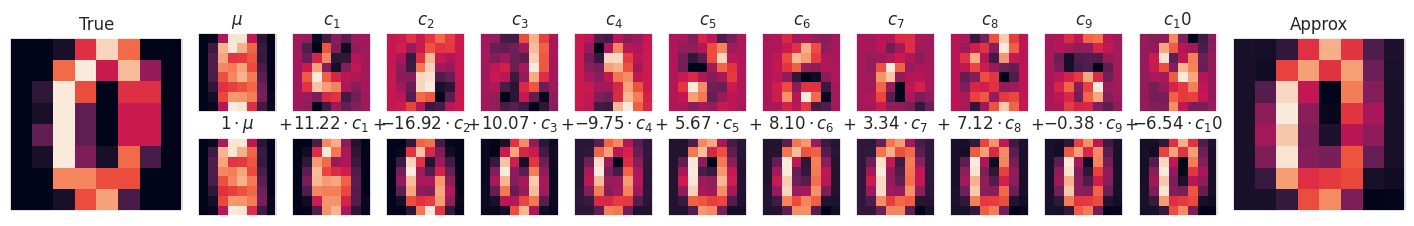

In [19]:
# reconstructing digit = 0 at index 10 in the digits data via PCA
pca = PCA(n_components=10)
Xproj = pca.fit_transform(digits.data)
fig = plot_pca_components(digits.data[10], Xproj[10],
                          pca.mean_, pca.components_)

**IT IS IMPORTANT TO NOTE THAT:**

- The PCA basis allows us to recover the salient features of the input image with just a mean plus eight components!

- PCA provides a low-dimensional representation of the data: it discovers a set of basis functions that are more efficient than the native pixel-basis of the input data.

### Choosing the number of components

In practice, we need to know how many principan components to use to describe the data. PCA can provide an estimate for that. We can look at the **cumulative explained variance ratio** as a function of the number of components to determine it:

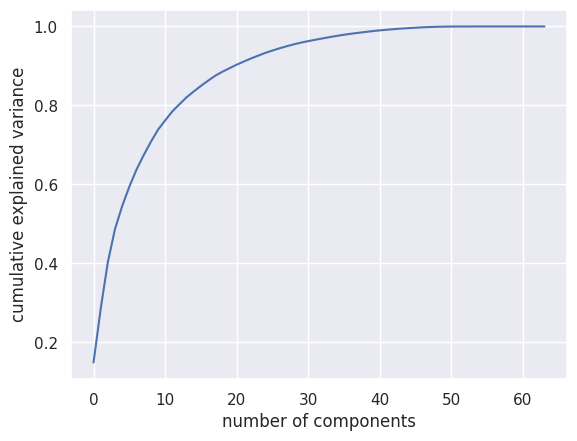

In [14]:
pca = PCA().fit(digits.data)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

The cumulative explained variance ratio curve quantifies how much of the total, 64-dimensional variance is contained within the first $N$ components.


For example, we observe that the first 10 components contain approximately 75% of the variance, while you need around 50 components to describe close to 100% of the variance. Also, if we pick up a two-dimensional projection, it loses  a lot of information s measured by the explained variance. We need about 20 components to retain 90% of the variance.  

<font color = 'red'> We emphasize that looking at the cumulative explained variance ratio plot for a high-dimensional dataset can help you understand the level of redundancy present in multiple observations. </font>


## PCA as Noise Filtering

<font color = 'red'> PCA can also be used as a filtering approach for noisy data! </font>

The idea is this:
- any components with variance much larger than the effect of the noise should be relatively unaffected by the noise.

- if you reconstruct the data using just the largest subset of principal components, you should be preferentially keeping the signal and throwing out the noise.

Let's see how this looks with the hand-written digits data.
First we will plot several of the input noise-free data:

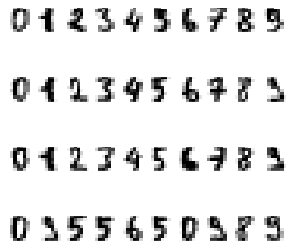

In [ ]:
def plot_digits(data):
    fig, axes = plt.subplots(4, 10, figsize=(5, 5),
                             subplot_kw={'xticks':[], 'yticks':[]},
                             gridspec_kw=dict(hspace=0.1, wspace=0.1))
    for i, ax in enumerate(axes.flat):
        ax.imshow(data[i].reshape(8, 8),
                  cmap='binary', interpolation='nearest',
                  clim=(0, 16))
plot_digits(digits.data)

Now lets add some random noise to create a noisy dataset, and re-plot it:

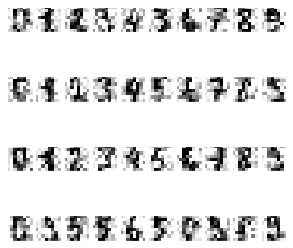

In [ ]:
np.random.seed(1)
# draw random samples from a normal (Gaussian) distribution with mean array of digits.data and standard deviation of 4

noisy = np.random.normal(digits.data,4)
plot_digits(noisy)

It's clear by eye that the images are noisy, and contain spurious pixels.
Let's train a PCA on the noisy data, requesting that the projection preserve 50% of the variance:

In [ ]:
pca = PCA(0.50).fit(noisy) # note how we can use a percentage (as a float) to indicate % of variance preserved
pca.n_components_

12

50% of the variance amounts to 12 principal components. We ca compute these components, and then use the inverse of the transform to reconstruct the filtered digits:

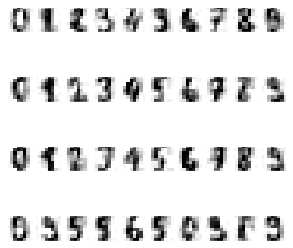

In [ ]:
components = pca.transform(noisy)               # apply dimensionality reduction to noisy data.
filtered = pca.inverse_transform(components)    # transform data back to its original space - filtered data.
plot_digits(filtered)                           # plot the filtered data.

This <font color = 'red'> signal preserving/noise filtering property </font> makes PCA a very useful feature selection routine!


For example:
- rather than training a classifier on very high-dimensional data, you might instead train the classifier on the lower-dimensional representation, which will automatically serve to filter out random noise in the inputs!

## Example: Eigenfaces

In our lesson covering Support Vector Machines (SVM)s, we explored an example of facial recognition with a support vector machine classifier in which we used a PCA projection into lower dimensional data as a feature selector.

In this example, we are going to take a look back and explore in more detail how it worked.


In [ ]:
# recall that this dataset is available in sklearn.datasets module
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_lfw_people.html

from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people()
print(faces.target_names)
print(faces.data.shape)
print(faces.images.shape)

['AJ Cook' 'AJ Lamas' 'Aaron Eckhart' ... 'Zumrati Juma' 'Zurab Tsereteli'
 'Zydrunas Ilgauskas']
(13233, 2914)
(13233, 62, 47)


Let us take a look at the principal axes that span this dataset!

-  Because this is a large dataset, we will use ``RandomizedPCA``
- ``RandomizedPCA`` contains a randomized method to approximate the first $N$ principal components much more quickly than the standard ``PCA`` estimator
- ``RandomizedPCA`` is very useful for high-dimensional data (here, we have a dimensionality of 2914).

We will take a look at the first 150 components:

In [ ]:
from sklearn.decomposition import PCA as RandomizedPCA       # RandomizedPCA is simply a parameter in PCA().
pca = RandomizedPCA(150)
pca.fit(faces.data)        # fit the model with faces.data by extracting the first 150 principal components.

PCA(copy=True, iterated_power='auto', n_components=150, random_state=None,
    svd_solver='auto', tol=0.0, whiten=False)

In [ ]:
pca.components_.shape       # 150 components each is an array of length 2914, original number of dimensions

(150, 2914)

In [ ]:
pca.components_[0].reshape(62,47).shape    #reshaping each component by 62 x 47

(62, 47)

In this case, it can be interesting to visualize the images associated with the first several principal components (these components are technically known as <font color = 'red'> "eigenvectors," </font>. Thus, these types of images are often called <font color = 'red'> "eigenfaces" </font>.
As you can see in the following figure, they are as creepy as they sound:

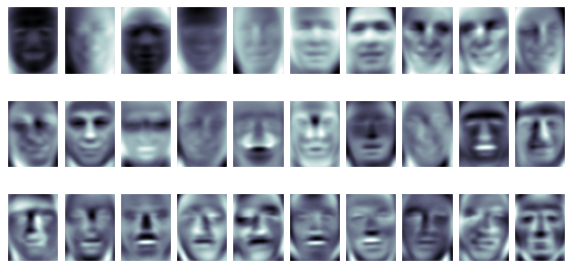

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(10, 5),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(62, 47), cmap='bone')       # note that each image is of 62 x 47 pixels

The results are very interesting, and give us insight into how the images vary: For example,

- the first few eigenfaces (from the top left) seem to be associated with the angle of lighting on the face,
- later principal vectors seem to be picking out certain features, such as eyes, noses, and lips.


Let's take a look at the cumulative variance of these components to see how much of the data the PCA projection is preserving:

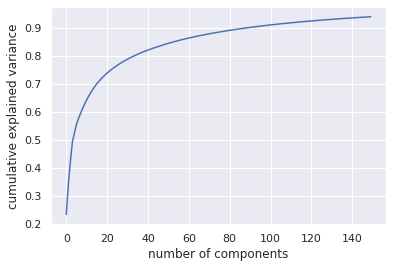

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

From the above cumulative explained variance plot, we observe that these 150 components account for just over 90% of the variance!

That would lead us to believe that using these 150 components, we would recover most of the essential characteristics of the data.
To make this more concrete, we can compare the input images with the images reconstructed from these 150 components:

In [ ]:
# Compute the components and projected faces
pca = RandomizedPCA(150).fit(faces.data)        # Fit the model with facea.data by extracting the first 150 principal components.
components = pca.transform(faces.data)          # Apply dimensionality reduction on faces.data.
projected = pca.inverse_transform(components)   # Transform data back to its original space - projected data

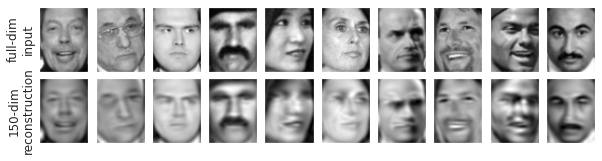

In [ ]:
# Plot the results original pictures versus projected ones
fig, ax = plt.subplots(2, 10, figsize=(10, 2.5),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
    ax[0, i].imshow(faces.data[i].reshape(62, 47), cmap='binary_r')
    ax[1, i].imshow(projected[i].reshape(62, 47), cmap='binary_r')

ax[0, 0].set_ylabel('full-dim\ninput')
ax[1, 0].set_ylabel('150-dim\nreconstruction');

The top row here shows the input images, while the bottom row shows the reconstruction of the images from just 150 of 2,914 initial features.


This visualization makes clear why the PCA feature selection used in Support Vector Machines (SVM)s was so successful:
- even though PCA reduces the dimensionality of the data by nearly a factor of 20 (From 2914 to 150), the projected images contain enough information that we might, even by eye, recognize the individuals in the image.
- our classification algorithm needs to be trained on 150-dimensional data rather than 2,914-dimensional data, which depending on the particular algorithm we choose, can lead to a much more efficient classification.

## Principal Component Analysis Summary

In this class we have discussed the use of principal component analysis for dimensionality reduction, for visualization of high-dimensional data, for noise filtering, and for feature selection within high-dimensional data.
Because of the versatility and interpretability of PCA, it has been shown to be effective in a wide variety of contexts and disciplines.

If you have any high-dimensional dataset to work with, you can start with PCA in order to visualize the relationship between points (as we did with the hand-written digits example), to understand the main variance in the data (as we did with the eigenfaces), and to understand the intrinsic dimensionality (by plotting the explained variance ratio).


- PCA is not useful for every high-dimensional dataset, however it offers a straightforward and efficient path to gaining insight into high-dimensional data!
- PCA's main weakness is that it tends to be highly affected by outliers in the data.
For this reason, many robust variants of PCA have been developed, many of which act to iteratively discard data points that are poorly described by the initial components.
Scikit-Learn contains a couple interesting variants on PCA, including ``RandomizedPCA`` and ``SparsePCA``, both also in the ``sklearn.decomposition`` submodule.
  - ``RandomizedPCA``, which we saw earlier, uses a non-deterministic method to quickly approximate the first few principal components in very high-dimensional data,
  - ``SparsePCA`` introduces a regularization term, similar to what we saw in Linear Regression that serves to enforce sparsity of the components.
